# Lab #1
Wednesday October 7th

Katie Merrill

Phys 434 AB 

Lab 1-- Wednesday October 7 2026

Katie Merrill

Phys 434 AB


# Part 1, Converting a Probability into a Sigma


## 1A About Normal Distributions

-  Normal distribution
    -  Bell Curve
    - When data has no  bias left or right, tends to be around a central value
    - mean=median= mode
    - symmetric
- Standard deviations
        - 68% of values are within 1 standard dev of the mean
        - 95%  of values are within 2 stand dev of the mean
        - Assuming data is normally distributed, if 95% of students at school are between 1.1 and 1.7m tall, then:
            - Mean= (1.1m+1.7m)/2=1.4m
            - Divide by the total number of standard deviations (95% = 2 on either side, 4 total)
            - 1 stand dev= (1.7m-1.1m)/4=0.15m= $\sigma$
    - z is the standard sscore (how many standard deviations from the mean)
          - eg, someone 1.85m tall is 3 standard deviations from the mean 1.4, therefore z-score=3
    - To standardize data, convert a a value toa  standard score (z score), subtract the mean, then divide by $\sigma$. Then the x axis should become in terms of sigma  (from Math is fun)
      - Z= $\frac{X-\mu}{\sigma}$ (from Wikipedia)
      


## 1B, Integrating the standard normal distribution:


In [87]:
import numpy as np
from scipy import stats
sigma= [1,2,3, 4, 5]
for s in sigma: 
    probability = stats.norm.cdf(s) # interal from s to infinity
    print (f"{s}, {probability}")

1, 0.8413447460685429
2, 0.9772498680518208
3, 0.9986501019683699
4, 0.9999683287581669
5, 0.9999997133484281


The values that I got for the first 5 values of sigma match the values for the Z table on wikipedia

## 1C, Determining the associated $\sigma$ value from  a given probability

In [93]:
probabilities= [0.8413447460685429, 0.9772498680518208, 0.9986501019683699, 0.9999683287581669, 0.9999997133484281]

for p in probabilities: 
    sigma = stats.norm.ppf(1-p)
    print (f"{p}, {sigma}")

0.8413447460685429, -1.0
0.9772498680518208, -2.0000000000000004
0.9986501019683699, -2.9999999999999982
0.9999683287581669, -4.0
0.9999997133484281, -4.999999999970176


The negative sigma values are because when you subtract the probability, the value 1-p is below the mean.

# Part 2, Other continuous analytic distributions

## 2A, Exponential Distribution


From Wikipedia:
- Probability distributions of the distance between events in a process in which events occur continuously and independently at a constant average rate
- PDF (Probability density function): ${\lambda e^{-\lambda x}}$
    - where x is the random variable (typically time), lambda is the rate parameter (greater than 0)
- CDF (Cumulative Distribution Function):${1-e^{-\lambda x}}$
- Mean:	${ {\frac {1}{\lambda }}}$
- Median: ${\frac {\ln 2}{\lambda }}$
- Mode: 0
- A nice Graph I foundfrom datacamp.com:
![graph](https://media.datacamp.com/cms/ad_4nxexltl4iy-0awdy5gziu5qo9pbn3ecy8ssajrjno1d44xxcg7durlqc7jokg3jzyviwuzfsuvf5bdornfr09mb_fz-4jhji3usetbi68vtwpy5yti7fcfoifsnkxnc8d3tga4xeqw.png)


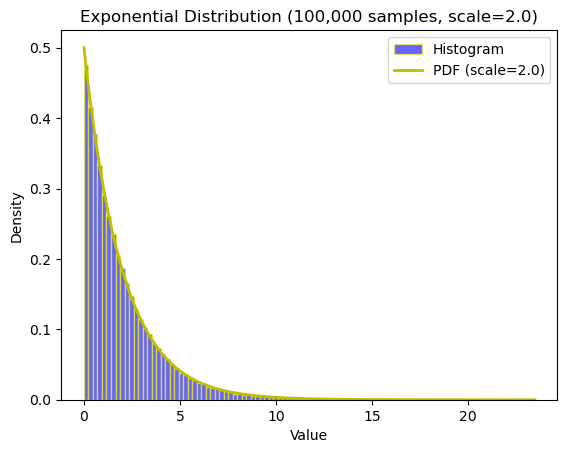

In [89]:
##2B

import matplotlib.pyplot as plt
import numpy as np
import scipy

#seed
np.random.seed(42)

# Parameters
n_samples = 100000
scale = 2.0  # Mean (beta = 1/lambda)

# 100k samples from the exponential distribution
samples = np.random.exponential(scale=scale, size=n_samples)

fig, ax=plt.subplots(1,1)

ax.hist(
    samples,
    bins=100,
    density=True,
    alpha=0.6,
    color="blue",
    edgecolor="yellow",
    label="Histogram",
)

x = np.linspace(0, max(samples), 1000)
pdf = (1.0 / scale) * np.exp(-x / scale)
plt.plot(x, pdf, "y-", lw=2, label=f"PDF (scale={scale})")

# Labels
plt.title(f"Exponential Distribution ({n_samples:,} samples, scale={scale})")
ax.set_xlabel("Value")
ax.set_ylabel("Density")

ax.legend()
plt.show()


# Part 3, Determining the sigma for a measurement from signal free data following exponential distribution

## 3A
Hypothetical Value: 5


## 3B
Statistical Question: What is the probability of a measurement reading 5 on the exponential distribution ?

## 3C
Integral from 5 to infinity of the exponential distribution:

$\int_{5}^{\infty} \lambda e^{-\lambda x} \, dx = e^{-5\lambda}$


## 3D: Calculate probability that the background produced the signal

In [90]:
probability= scipy.stats.expon.cdf(5)
print (probability)

0.9932620530009145


## 3E: Convert probability into an equivalent sigma

In [91]:
p = 0.9932620530009145
sigma = stats.norm.ppf(1 - p)
print (f"The equivalent sigma value for {p} is {sigma}")

The equivalent sigma value for 0.9932620530009145 is -2.4709386372615882


# Part 4:


In [92]:
signals = [1,2,3,4,5,6,7]
for k in signals:
    probability= scipy.stats.expon.cdf(k)
    sigma = stats.norm.ppf(probability)
    print (f"{k}, {probability}, {sigma}")

1, 0.6321205588285577, 0.33747496376420244
2, 0.8646647167633873, 1.1015196284987503
3, 0.950212931632136, 1.6469217205277145
4, 0.9816843611112658, 2.0898499829712565
5, 0.9932620530009145, 2.4709386372615882
6, 0.9975212478233336, 2.8097821525607745
7, 0.9990881180344455, 3.1175251374126494


Based on the different hypothetical measurements I tested out, the closer the signal is to 0, the lower the sigma. 7 has a sigma value of over 3, meaning that it is statistically significant piece of data and is not caused by the background.